In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import random
import numpy as np

from collections import deque
from torch.distributions import Categorical


import matplotlib.pyplot as plt

In [2]:
# =========================================================
# CREATE CARTPOLE ENVIRONMENT
# =========================================================

env = gym.make(

    "CartPole-v1"

)


# =========================================================
# STATE + ACTION INFORMATION
# =========================================================

print(

    "Observation Space Shape:",
    env.observation_space.shape

)

print(

    "Number of Actions:",
    env.action_space.n

)

Observation Space Shape: (4,)
Number of Actions: 2


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PolicyNetwork(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(4,128)

        self.fc2 = nn.Linear(  128, 128
        )

        self.fc3 = nn.Linear(
            128,
            2
        )

    def forward(self, x):

        x = F.relu(
            self.fc1(x)
        )

        x = F.relu(
            self.fc2(x)
        )

        logits = self.fc3(x)

        return logits

    
    

In [4]:
policy_net = PolicyNetwork()

# dummy_states = torch.randn(1,4)

# output = model(dummy_states)
# print(output.shape)
# print(output)


In [5]:
def select_action(
    state,
    policy_net
):

    state_tensor = (
        torch.FloatTensor(state)
        .unsqueeze(0)
    )

    logits = policy_net(
        state_tensor
    )

    dist = Categorical(
        logits=logits
    )

    action = dist.sample()

    log_prob = dist.log_prob(
        action
    )

    return (
        action.item(),
        log_prob
    )

In [6]:
state, info = env.reset()

action, log_prob = select_action(
    state,
    policy_net
)

print(action)
print(log_prob)

0
tensor([-0.6343], grad_fn=<SqueezeBackward1>)


In [7]:
# def store_transtition(self,state_tensor,action.items(),log_prob):


#     reward_memory = []
#     observation_memory = []
#     action_memory = []
#     log_prob_memory = []

#     observation.append(state_tensor)
#     action_memory.append(action.itmes())
#     reward_memory.append(reward)
#     log_prob_memory.append(log_prob)

#     return reward_memory,observation_memory,action_memory,log_prob_memory


In [8]:
def compute_returns(
    rewards,
    gamma=0.99
):

    returns = []

    G = 0

    for reward in reversed(rewards):

        G = reward + gamma * G

        returns.insert(
            0,
            G
        )

    returns = torch.tensor(
        returns,
        dtype=torch.float32
    )

    returns = (
        returns - returns.mean()
    ) / (
        returns.std() + 1e-8
    )

    return returns

In [9]:
def update_policy(
    log_probs,
    returns,
    optimizer
):

    loss = 0

    for log_prob, G in zip(
        log_probs,
        returns
    ):

        loss += -log_prob * G

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    return loss.item()

In [10]:
def train_reinforce(
    env,
    policy_net,
    optimizer,
    num_episodes=500,
    gamma=0.90
):

    reward_history = []

    for episode in range(num_episodes):

        state, info = env.reset()

        log_prob_store = []
        reward_store = []

        done = False
        total_reward = 0

        while not done:

            action, log_prob = select_action(
                state,
                policy_net
            )

            next_state, reward, terminated, truncated, info = env.step(
                action
            )

            log_prob_store.append(
                log_prob
            )

            reward_store.append(
                reward
            )

            total_reward += reward

            state = next_state

            done = (
                terminated
                or truncated
            )

        returns = compute_returns(
            reward_store,
            gamma
        )

        loss = update_policy(
            log_prob_store,
            returns,
            optimizer
        )

        reward_history.append(
            total_reward
        )

        print(
            f"Episode {episode} | "
            f"Reward {total_reward} | "
            f"Loss {loss:.4f}"
        )

    return reward_history

In [ ]:
policy_net = PolicyNetwork()

optimizer = torch.optim.Adam(
    policy_net.parameters(),
    lr=1e-3
)

reward_history = train_reinforce(
    env,
    policy_net,
    optimizer,
    num_episodes=500
)

Episode 0 | Reward 48.0 | Loss 0.8984
Episode 1 | Reward 27.0 | Loss -0.1142
Episode 2 | Reward 29.0 | Loss -0.4762
Episode 3 | Reward 31.0 | Loss -0.7289
Episode 4 | Reward 19.0 | Loss 0.0804
Episode 5 | Reward 33.0 | Loss -0.7094
Episode 6 | Reward 15.0 | Loss 0.5520
Episode 7 | Reward 74.0 | Loss -1.8347
Episode 8 | Reward 17.0 | Loss -0.7886
Episode 9 | Reward 22.0 | Loss -1.7441
Episode 10 | Reward 16.0 | Loss 0.0904
Episode 11 | Reward 95.0 | Loss -0.5565
Episode 12 | Reward 29.0 | Loss -0.3374
Episode 13 | Reward 37.0 | Loss -1.1107
Episode 14 | Reward 16.0 | Loss 1.5059
Episode 15 | Reward 29.0 | Loss 0.1047
Episode 16 | Reward 58.0 | Loss -3.8683
Episode 17 | Reward 25.0 | Loss 0.9355
Episode 18 | Reward 32.0 | Loss 0.5032
Episode 19 | Reward 33.0 | Loss -0.5763
Episode 20 | Reward 34.0 | Loss -3.3589
Episode 21 | Reward 34.0 | Loss -1.6912
Episode 22 | Reward 68.0 | Loss -1.0250
Episode 23 | Reward 19.0 | Loss 1.5047
Episode 24 | Reward 16.0 | Loss -0.4448
Episode 25 | Reward

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    reward_history
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Reward"
)

plt.title(
    "REINFORCE on CartPole"
)

plt.grid(True)

plt.show()

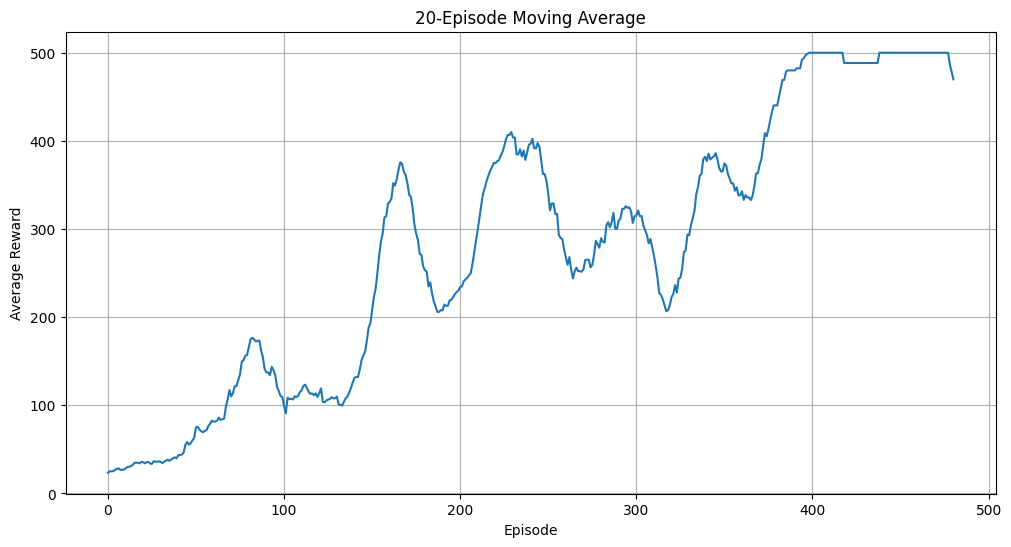

In [ ]:
import numpy as np

window = 20

moving_avg = np.convolve(
    reward_history,
    np.ones(window)/window,
    mode="valid"
)

plt.figure(figsize=(12,6))

plt.plot(
    moving_avg
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Average Reward"
)

plt.title(
    "20-Episode Moving Average"
)

plt.grid(True)

plt.show()